## What Is a Gain Chart?

A Gain Chart shows how well a classification model captures positive cases compared to random selection.

### PART 1 — Create Sample Classification Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression


In [2]:
# Generate dataset
X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X, y)

# Predicted probabilities
y_prob = model.predict_proba(X)[:, 1]

df = pd.DataFrame({
    "y_true": y,
    "y_prob": y_prob
})


### PART 2 — Sort by Predicted Probability

In [3]:
df = df.sort_values("y_prob", ascending=False).reset_index(drop=True)


### PART 3 — Create Deciles

In [4]:
df["decile"] = pd.qcut(df.index, 10, labels=False)


### PART 4 — Build Gain Table

In [5]:
gain_table = (
    df.groupby("decile")
      .agg(
          total=("y_true", "count"),
          positives=("y_true", "sum")
      )
      .reset_index()
)

gain_table["cum_positives"] = gain_table["positives"].cumsum()
gain_table["total_positives"] = gain_table["positives"].sum()

gain_table["cumulative_gain"] = (
    gain_table["cum_positives"] / gain_table["total_positives"]
)

gain_table


,decile,total,positives,cum_positives,total_positives,cumulative_gain
0,0,100,87,87,499,0.174349
1,1,100,82,169,499,0.338677
2,2,100,67,236,499,0.472946
3,3,100,57,293,499,0.587174
4,4,100,54,347,499,0.695391
5,5,100,41,388,499,0.777555
6,6,100,34,422,499,0.845691
7,7,100,29,451,499,0.903808
8,8,100,32,483,499,0.967936
9,9,100,16,499,499,1.000000


### PART 5 — Gain Chart (Core Visualization)

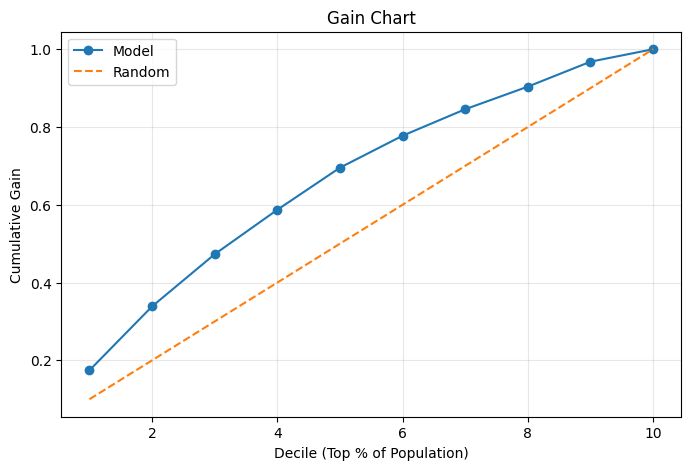

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    gain_table["decile"] + 1,
    gain_table["cumulative_gain"],
    marker="o",
    label="Model"
)

# Random model baseline
plt.plot(
    gain_table["decile"] + 1,
    (gain_table["decile"] + 1) / 10,
    linestyle="--",
    label="Random"
)

plt.xlabel("Decile (Top % of Population)")
plt.ylabel("Cumulative Gain")
plt.title("Gain Chart")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### PART 6 — Gain Chart Using Percent Population (Cleaner)

In [7]:
gain_table["population_pct"] = (gain_table["decile"] + 1) / 10


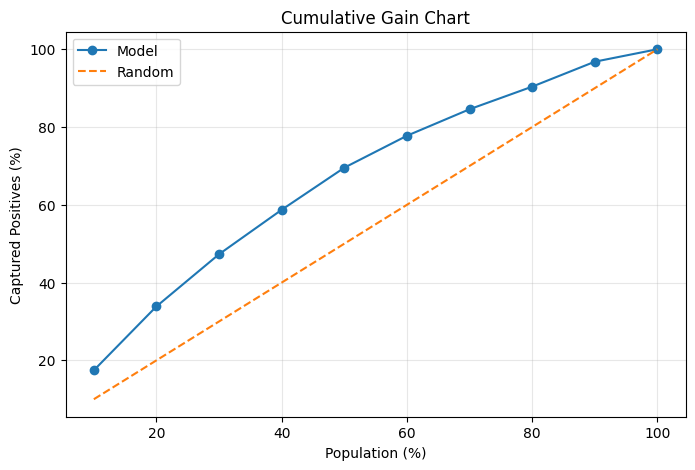

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    gain_table["population_pct"] * 100,
    gain_table["cumulative_gain"] * 100,
    marker="o",
    label="Model"
)

plt.plot(
    gain_table["population_pct"] * 100,
    gain_table["population_pct"] * 100,
    linestyle="--",
    label="Random"
)

plt.xlabel("Population (%)")
plt.ylabel("Captured Positives (%)")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### PART 7 — Gain Chart as Bar Plot

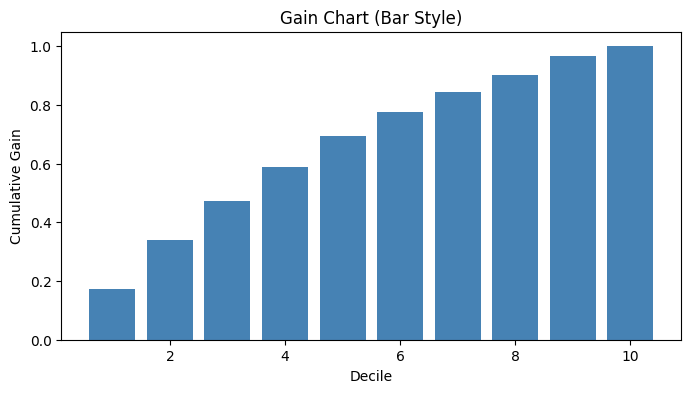

In [9]:
plt.figure(figsize=(8, 4))
plt.bar(
    gain_table["decile"] + 1,
    gain_table["cumulative_gain"],
    color="steelblue"
)

plt.xlabel("Decile")
plt.ylabel("Cumulative Gain")
plt.title("Gain Chart (Bar Style)")
plt.show()


### PART 8 — Gain Chart Function (Reusable)

In [10]:
def gain_chart(y_true, y_prob, bins=10):
    df = pd.DataFrame({"y": y_true, "prob": y_prob})
    df = df.sort_values("prob", ascending=False).reset_index(drop=True)

    df["bin"] = pd.qcut(df.index, bins, labels=False)

    summary = (
        df.groupby("bin")
        .agg(
            total=("y", "count"),
            positives=("y", "sum")
        )
        .reset_index()
    )

    summary["cum_pos"] = summary["positives"].cumsum()
    summary["total_pos"] = summary["positives"].sum()
    summary["gain"] = summary["cum_pos"] / summary["total_pos"]

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot((summary["bin"] + 1) / bins * 100, summary["gain"] * 100, marker="o")
    plt.plot(
        (summary["bin"] + 1) / bins * 100,
        (summary["bin"] + 1) / bins * 100,
        linestyle="--",
        label="Random"
    )

    plt.xlabel("Population (%)")
    plt.ylabel("Captured Positives (%)")
    plt.title("Gain Chart")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return summary


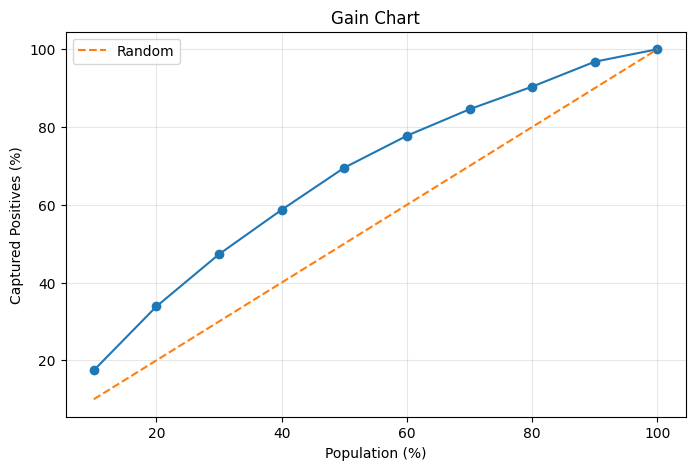

In [11]:
gain_table = gain_chart(y, y_prob)
